In [1]:
# PyMC + NUTS sanity check on a 10-D diagonal Gaussian
# - Generate synthetic data from known mu_true and sigma_true (diag covariance)
# - Build a model that estimates mu (one mean per dimension)
# - Use NUTS to sample posterior
# - Compare posterior mean + intervals to ground truth and z-scores

import numpy as np
import pymc as pm
import arviz as az

In [2]:
# ----------------------------
# 1) Data generation (known)
# ----------------------------
rng = np.random.default_rng(12345)

D = 10              # dimensions
N = 3000            # number of observations

mu_true = np.linspace(-3.0, 3.0, D)  # different mean in each dimension
sigma_true = np.array([0.4, 0.7, 1.2, 0.9, 0.5, 1.5, 0.8, 1.1, 0.6, 1.3])  # known std per dim

# X shape: (N, D), each column d is N(mu_true[d], sigma_true[d]^2)
X = rng.normal(loc=mu_true, scale=sigma_true, size=(N, D))

# closed-form MLE / sampling distribution check target for mu:
# sample mean is Normal(mu_true, (sigma_true/sqrt(N))^2)
xbar = X.mean(axis=0)
se_xbar = sigma_true / np.sqrt(N)

print("True mu:", mu_true)
print("Sample mean:", xbar)
print("Std error of sample mean:", se_xbar)
print("Z-scores (xbar - mu_true) / se:", (xbar - mu_true) / se_xbar)

True mu: [-3.         -2.33333333 -1.66666667 -1.         -0.33333333  0.33333333
  1.          1.66666667  2.33333333  3.        ]
Sample mean: [-3.00000955 -2.32269942 -1.65083541 -1.01291253 -0.32348247  0.29601335
  1.01030598  1.65206513  2.34584419  3.02088223]
Std error of sample mean: [0.00730297 0.01278019 0.0219089  0.01643168 0.00912871 0.02738613
 0.01460593 0.02008316 0.01095445 0.02373464]
Z-scores (xbar - mu_true) / se: [-1.30833260e-03  8.32061932e-01  7.22594648e-01 -7.85831470e-01
  1.07910748e+00 -1.36273314e+00  7.05602529e-01 -7.27053642e-01
  1.14207957e+00  8.79820724e-01]


In [22]:
# ----------------------------
# 2) PyMC model + NUTS
# ----------------------------
# We estimate mu (vector length D). Variances are known and diagonal.
# Use a fairly weak prior relative to the likelihood.
with pm.Model() as model:
    mu = pm.Normal("mu", mu=0.0, sigma=10.0, shape=D)

    # Likelihood: independent dims given mu (diagonal covariance)
    # PyMC will broadcast sigma_true (shape D) over observations (N, D)
    y = pm.Normal("y", mu=mu, sigma=sigma_true, observed=X)

    # NUTS sampling
    idata = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        cores=4, 
        target_accept=0.9,
        random_seed=2026,
        nuts_sampler="pymc",  # explicit NUTS backend
        progressbar=True,
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 11 seconds.


In [25]:
stats = idata.sample_stats
print(list(stats.data_vars))
tree_depth = idata.sample_stats["tree_depth"].to_numpy()
leapfrog_est = 2 ** tree_depth          # per draw (rough but commonly used)
total_grad_evals_est = leapfrog_est.sum()
print("Estimate:", total_grad_evals_est)
print("Step sum:", stats["n_steps"].to_numpy().sum())

['energy', 'max_energy_error', 'tree_depth', 'index_in_trajectory', 'largest_eigval', 'step_size_bar', 'energy_error', 'process_time_diff', 'diverging', 'step_size', 'divergences', 'n_steps', 'lp', 'reached_max_treedepth', 'smallest_eigval', 'acceptance_rate', 'perf_counter_start', 'perf_counter_diff']
Estimate: 62016
Step sum: 54016.0


In [4]:
# ----------------------------
# 3) Diagnostics + result checks
# ----------------------------
summary = az.summary(idata, var_names=["mu"], round_to=4)
display(summary)

# Posterior mean estimate for mu
mu_post_mean = idata.posterior["mu"].mean(dim=("chain", "draw")).values
mu_post_sd = idata.posterior["mu"].std(dim=("chain", "draw")).values

print("\nPosterior mean(mu):", mu_post_mean)
print("Posterior sd(mu):  ", mu_post_sd)
print("True mu:           ", mu_true)

# Credible intervals + coverage check
hdi = az.hdi(idata, var_names=["mu"], hdi_prob=0.95)["mu"].values  # shape (D, 2)
covered = (mu_true >= hdi[:, 0]) & (mu_true <= hdi[:, 1])

print("\n95% HDI for each dimension (low, high):")
for d in range(D):
    print(f"d={d:2d}  HDI=({hdi[d,0]: .4f}, {hdi[d,1]: .4f})  true={mu_true[d]: .4f}  covered={covered[d]}")

print("\nCoverage count:", covered.sum(), "/", D)

# Compare to analytic posterior for Normal likelihood with Normal prior:
# prior: mu_d ~ Normal(0, 10^2)
# likelihood: x_i,d ~ Normal(mu_d, sigma_true[d]^2)
# posterior: mu_d | X ~ Normal(m_post, v_post)
prior_var = 10.0**2
like_var = sigma_true**2
post_var_analytic = 1.0 / (1.0/prior_var + N/like_var)
post_mean_analytic = post_var_analytic * (0.0/prior_var + N*xbar/like_var)

print("\nAnalytic posterior mean:", post_mean_analytic)
print("Analytic posterior sd:  ", np.sqrt(post_var_analytic))

print("\nAbs error (NUTS mean - analytic mean):", np.abs(mu_post_mean - post_mean_analytic))
print("Max abs error:", np.max(np.abs(mu_post_mean - post_mean_analytic)))

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu[0],-3.0000,0.0072,-3.0132,-2.9863,0.0001,0.0001,17773.3193,5754.9869,1.0008
mu[1],-2.3228,0.0128,-2.3459,-2.2980,0.0001,0.0002,19164.5670,5775.7913,1.0017
mu[2],-1.6509,0.0215,-1.6901,-1.6092,0.0002,0.0003,16234.9795,5257.8550,1.0009
mu[3],-1.0127,0.0165,-1.0429,-0.9815,0.0001,0.0002,16637.7853,5767.4450,1.0002
mu[4],-0.3235,0.0091,-0.3403,-0.3063,0.0001,0.0001,15739.1497,4987.5583,1.0002
mu[5],0.2960,0.0268,0.2432,0.3450,0.0002,0.0004,19147.2342,5748.6318,1.0006
mu[6],1.0103,0.0144,0.9828,1.0371,0.0001,0.0002,16612.8603,5751.5285,1.0003
mu[7],1.6522,0.0198,1.6143,1.6893,0.0001,0.0003,18396.4169,5814.7389,1.0007
mu[8],2.3459,0.0111,2.3262,2.3672,0.0001,0.0001,18132.1638,5955.9308,1.0006
mu[9],3.0209,0.0242,2.9736,3.0641,0.0002,0.0003,15881.2559,5890.6084,1.0005



Posterior mean(mu): [-2.99998774 -2.32284204 -1.65086305 -1.01267422 -0.32353993  0.29603391
  1.01033308  1.65218968  2.34592051  3.02087774]
Posterior sd(mu):   [0.0072416  0.01276433 0.02145969 0.01652968 0.0090592  0.02684038
 0.01437405 0.01982203 0.01106188 0.02415921]
True mu:            [-3.         -2.33333333 -1.66666667 -1.         -0.33333333  0.33333333
  1.          1.66666667  2.33333333  3.        ]

95% HDI for each dimension (low, high):
d= 0  HDI=(-3.0146, -2.9865)  true=-3.0000  covered=True
d= 1  HDI=(-2.3475, -2.2977)  true=-2.3333  covered=True
d= 2  HDI=(-1.6928, -1.6088)  true=-1.6667  covered=True
d= 3  HDI=(-1.0434, -0.9797)  true=-1.0000  covered=True
d= 4  HDI=(-0.3410, -0.3057)  true=-0.3333  covered=True
d= 5  HDI=( 0.2433,  0.3497)  true= 0.3333  covered=True
d= 6  HDI=( 0.9818,  1.0384)  true= 1.0000  covered=True
d= 7  HDI=( 1.6140,  1.6923)  true= 1.6667  covered=True
d= 8  HDI=( 2.3245,  2.3672)  true= 2.3333  covered=True
d= 9  HDI=( 2.9736,  3.067

/home/mattia/anaconda3/envs/alice/lib/python3.13/site-packages/arviz/plots/backends/matplotlib/pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


array([[<Axes: ylabel='mu\n0'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='mu\n1'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='mu\n2'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='mu\n3'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='mu\n4'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='mu\n5'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='mu\n6'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: xlabel='mu\n0', ylabel='mu\n7'>, <Axes: xlabel='mu\n1'>,
        <Axes: xlabel='mu\n2'>, <Axes: xlabel='mu\n3'>,
        <Axes: xlabel='mu\n4'>, <Axes: xlabel='mu\n5'>,
        <Axes: xlabel='mu\n6'>, <Axes: 

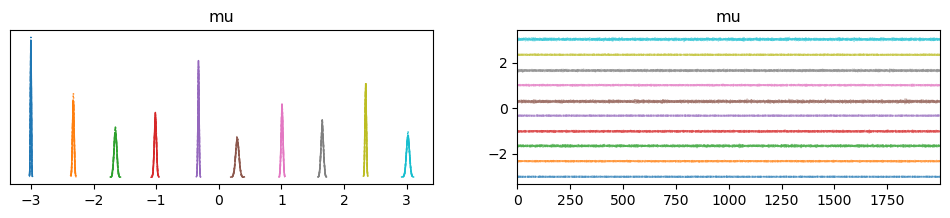

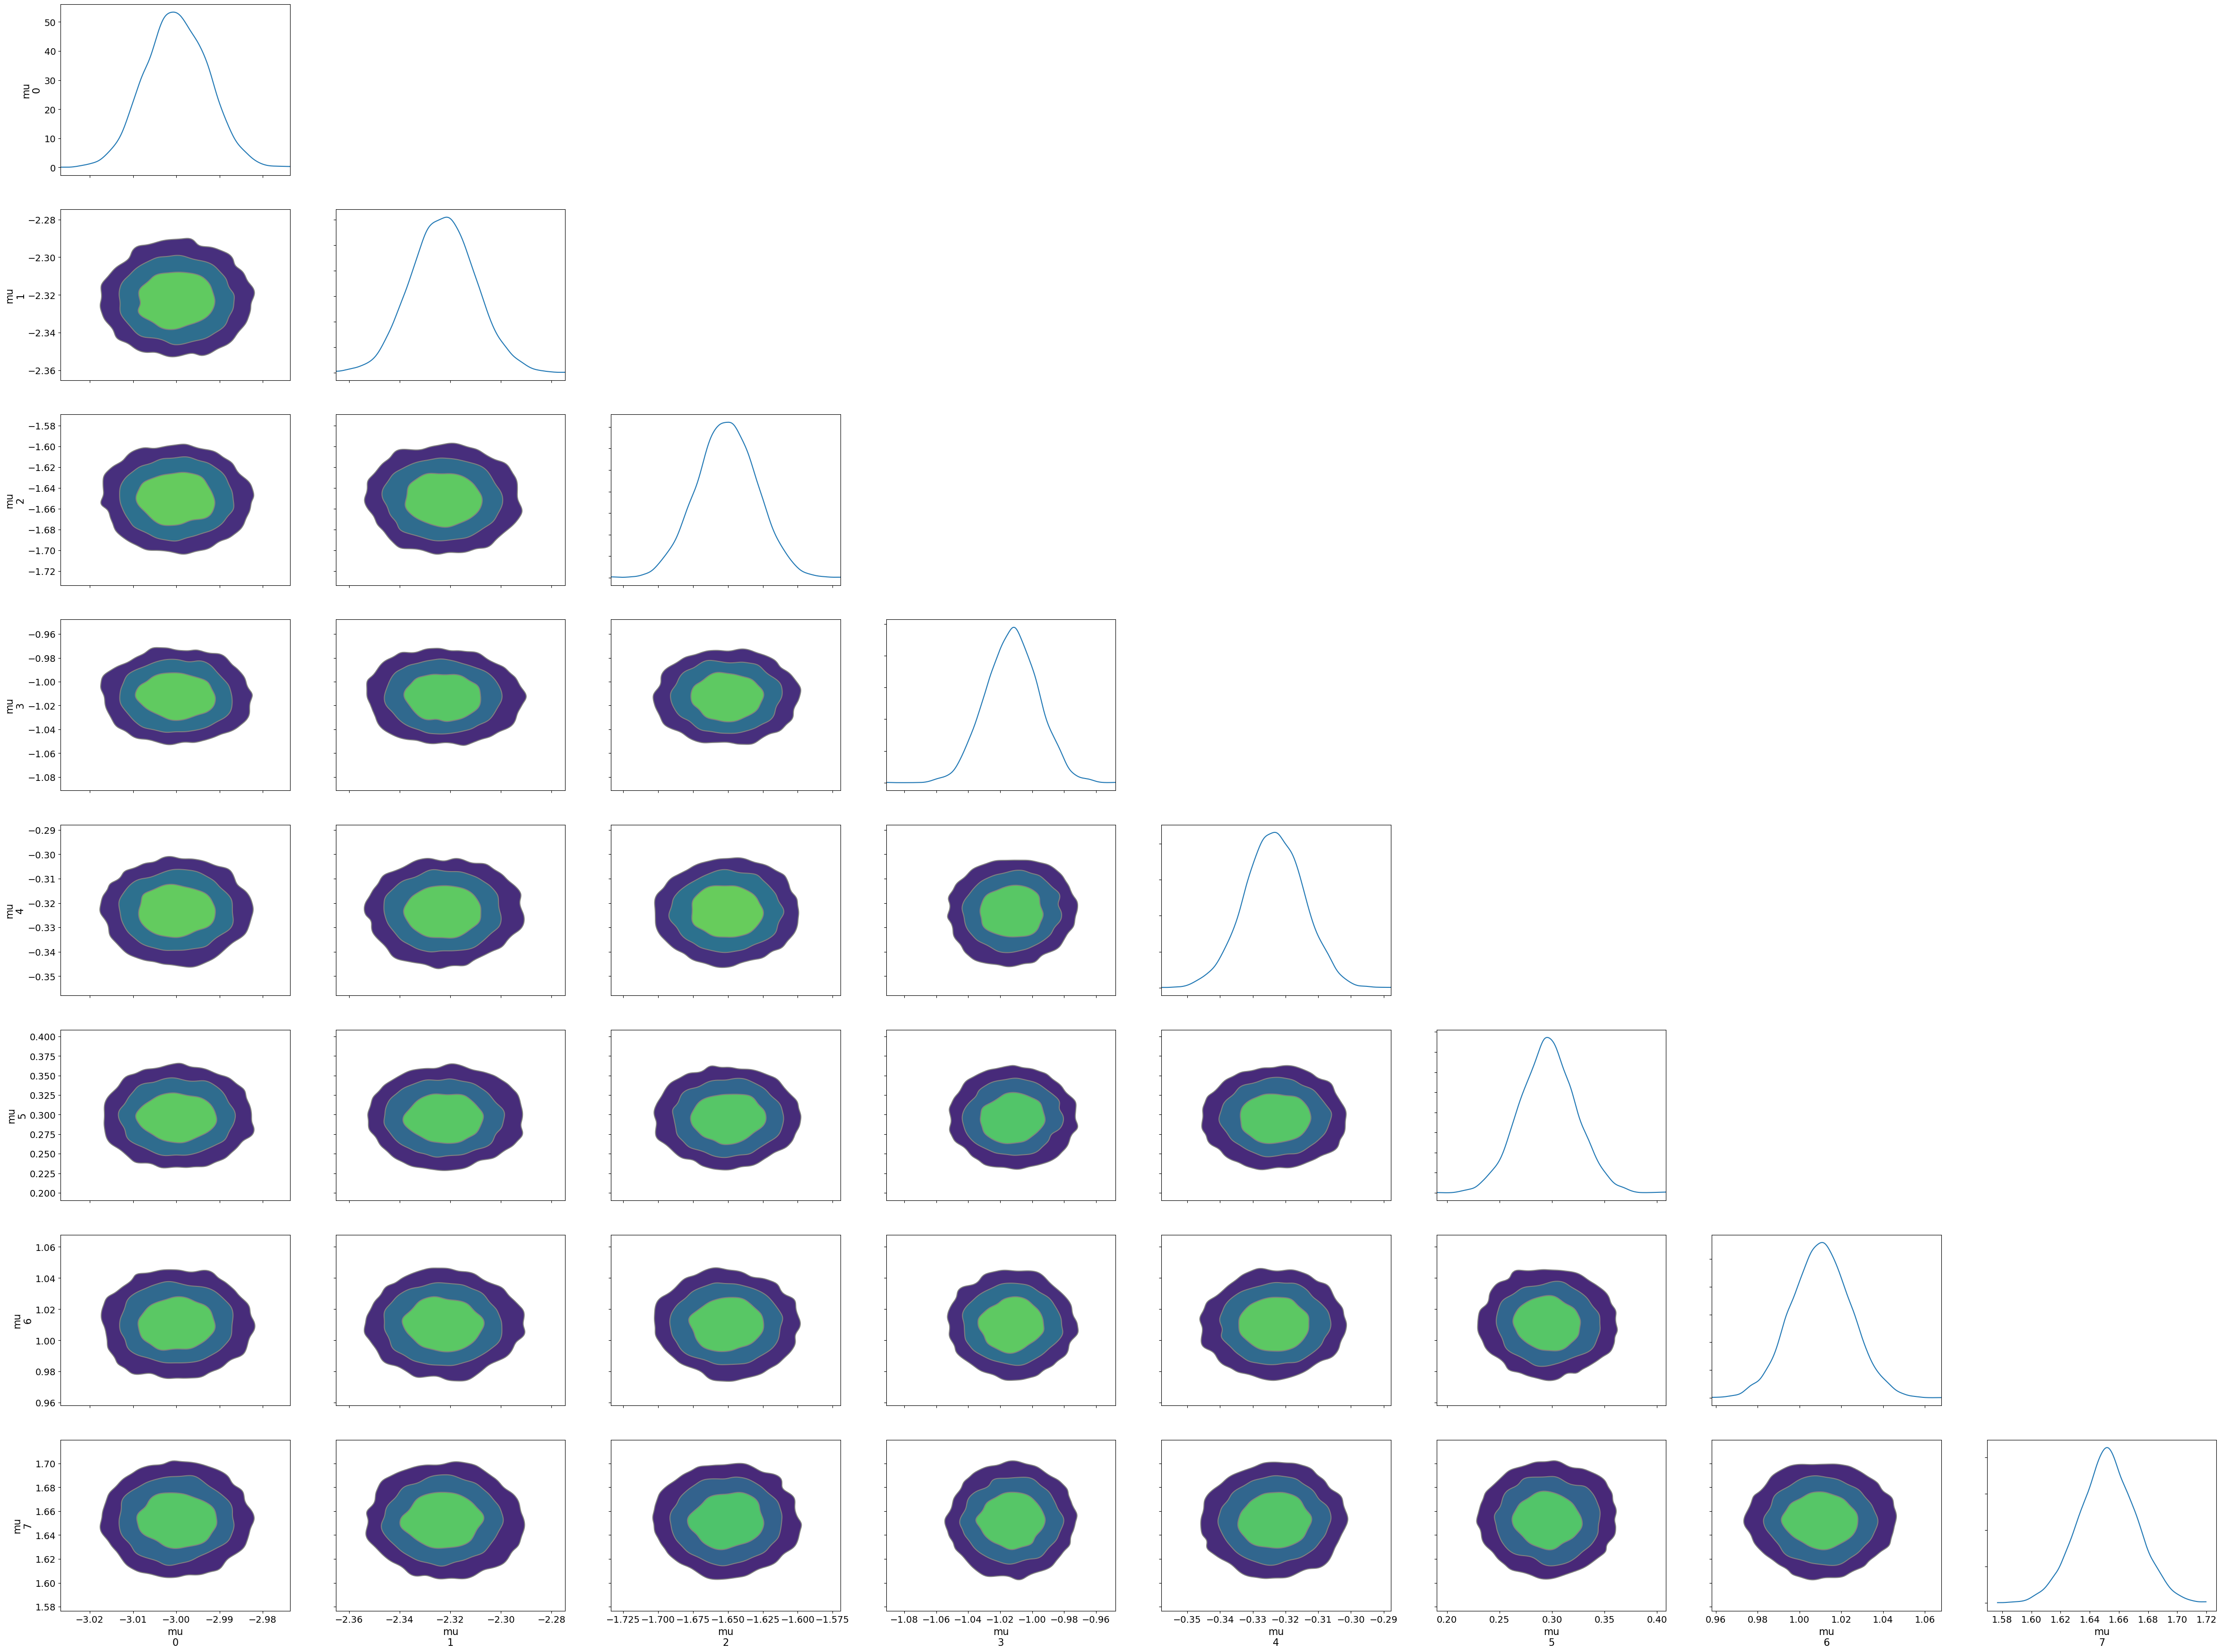

In [5]:
# quick trace + pair plots for sanity
az.plot_trace(idata, var_names=["mu"])
az.plot_pair(idata, var_names=["mu"], kind="kde", marginals=True)

Initializing NUTS using jitter+adapt_diag...


mu_true: [-3.         -2.33333333 -1.66666667 -1.         -0.33333333  0.33333333
  1.          1.66666667  2.33333333  3.        ]
xbar:    [-2.99873694 -2.32426576 -1.6526318  -1.00370521 -0.32522294  0.31436754
  1.00574597  1.64380535  2.34472408  3.01715665]

Analytic posterior mean: [-2.99873635 -2.32426348 -1.65262231 -1.00370224 -0.32522276  0.31436252
  1.00574514  1.64379725  2.34472468  3.01714359]
Analytic posterior sd (diag): [0.00632455 0.01106796 0.01897362 0.01423023 0.00790569 0.023717
 0.01264909 0.0173925  0.00948682 0.02055476]


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu]


Output()

Sampling 2 chains for 100 tune and 45 draw iterations (200 + 90 draws total) took 62 seconds.
The number of samples is too small to check convergence reliably.



Posterior mean (NUTS): [-2.99886908 -2.32575271 -1.65130848 -1.00241916 -0.32413522  0.31148305
  1.00478735  1.64504846  2.34437827  3.01870507]
Posterior sd   (NUTS): [0.0067839  0.01247622 0.01806446 0.01730963 0.00794681 0.02697133
 0.01425212 0.0169259  0.00898453 0.02283773]

Abs error vs analytic mean: [0.00013274 0.00148922 0.00131383 0.00128308 0.00108754 0.00287947
 0.00095779 0.00125121 0.00034641 0.00156148]
Max abs error: 0.002879473105116659

95% HDI coverage of true mu:
d= 0  HDI=(-3.0107, -2.9850)  true=-3.0000  covered=True
d= 1  HDI=(-2.3518, -2.3070)  true=-2.3333  covered=True
d= 2  HDI=(-1.6811, -1.6103)  true=-1.6667  covered=True
d= 3  HDI=(-1.0319, -0.9706)  true=-1.0000  covered=True
d= 4  HDI=(-0.3403, -0.3101)  true=-0.3333  covered=True
d= 5  HDI=( 0.2623,  0.3666)  true= 0.3333  covered=True
d= 6  HDI=( 0.9783,  1.0314)  true= 1.0000  covered=True
d= 7  HDI=( 1.6162,  1.6785)  true= 1.6667  covered=True
d= 8  HDI=( 2.3303,  2.3635)  true= 2.3333  covered=T

array([[<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'mu'}>]],
      dtype=object)

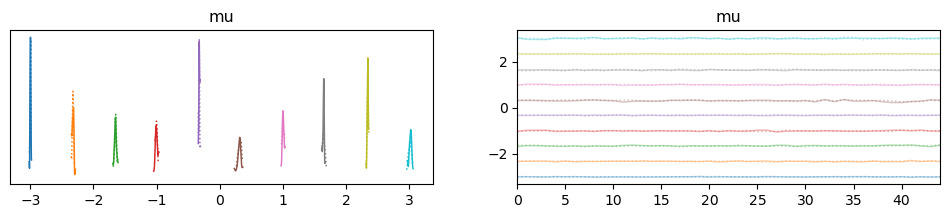

In [6]:
# Now with full covariance matrix

# Notes:
# - Use pm.MvNormal with chol=... for numerical stability

# ----------------------------
# 1) Generate correlated MVN data with known covariance
# ----------------------------
rng = np.random.default_rng(12345)

D = 10
N = 4000

mu_true = np.linspace(-3.0, 3.0, D)

# Build an SPD covariance with strong-ish correlations
sigmas = np.array([0.4, 0.7, 1.2, 0.9, 0.5, 1.5, 0.8, 1.1, 0.6, 1.3])
S = np.diag(sigmas)

# Random correlation matrix, then blend with I to control conditioning
A = rng.normal(size=(D, D))
R_unnorm = A @ A.T
d = np.sqrt(np.diag(R_unnorm))
R = R_unnorm / np.outer(d, d)

alpha = 0.75  # closer to 1 => stronger correlations
R = alpha * R + (1 - alpha) * np.eye(D)

Sigma_true = S @ R @ S
L_true = np.linalg.cholesky(Sigma_true)

# X ~ MVN(mu_true, Sigma_true)
X = mu_true + rng.normal(size=(N, D)) @ L_true.T
xbar = X.mean(axis=0)

print("mu_true:", mu_true)
print("xbar:   ", xbar)

# ----------------------------
# 2) Analytic posterior for mu (known Sigma, prior Normal)
# ----------------------------
# Prior: mu ~ N(0, tau^2 I)
tau = 10.0
prior_prec = (1.0 / tau**2) * np.eye(D)

Sigma_inv = np.linalg.inv(Sigma_true)
like_prec = N * Sigma_inv

post_prec = prior_prec + like_prec
post_cov = np.linalg.inv(post_prec)
post_mean = post_cov @ (N * Sigma_inv @ xbar)

print("\nAnalytic posterior mean:", post_mean)
print("Analytic posterior sd (diag):", np.sqrt(np.diag(post_cov)))

# ----------------------------
# 3) PyMC model (estimate mu only) + NUTS
# ----------------------------
with pm.Model() as model:
    mu = pm.Normal("mu", mu=0.0, sigma=tau, shape=D)

    # In PyMC 5.28.4, just pass the numpy chol directly (or use pm.Data if you prefer)
    y = pm.MvNormal("y", mu=mu, chol=L_true, observed=X)

    idata = pm.sample(
        draws=1000,
        tune=100,
        chains=4,
        cores=4,
        target_accept=0.8,
        random_seed=2026,
        progressbar=True,
    )

# ----------------------------
# 4) Compare NUTS posterior to analytic posterior
# ----------------------------
mu_post_mean = idata.posterior["mu"].mean(dim=("chain", "draw")).values
mu_post_sd   = idata.posterior["mu"].std(dim=("chain", "draw")).values

print("\nPosterior mean (NUTS):", mu_post_mean)
print("Posterior sd   (NUTS):", mu_post_sd)

abs_err = np.abs(mu_post_mean - post_mean)
print("\nAbs error vs analytic mean:", abs_err)
print("Max abs error:", abs_err.max())

# 95% HDI coverage of the TRUE mu (sanity check)
hdi = az.hdi(idata, var_names=["mu"], hdi_prob=0.95)["mu"].values  # (D, 2)
covered = (mu_true >= hdi[:, 0]) & (mu_true <= hdi[:, 1])

print("\n95% HDI coverage of true mu:")
for d in range(D):
    print(f"d={d:2d}  HDI=({hdi[d,0]: .4f}, {hdi[d,1]: .4f})  true={mu_true[d]: .4f}  covered={covered[d]}")
print("Coverage count:", covered.sum(), "/", D)

# Diagnostics
print("\nDiagnostics (r_hat, ESS):")
print(az.summary(idata, var_names=["mu"])[["r_hat", "ess_bulk", "ess_tail"]])

# Optional: trace
az.plot_trace(idata, var_names=["mu"])

## HMC Test

In [35]:
with pm.Model() as model:
    mu = pm.Normal("mu", mu=0.0, sigma=10.0, shape=D)

    # Likelihood: independent dims given mu (diagonal covariance)
    # PyMC will broadcast sigma_true (shape D) over observations (N, D)
    y = pm.Normal("y", mu=mu, sigma=sigma_true, observed=X)

    step = pm.HamiltonianMC(target_accept=0.9, path_length=2.0)

    # NUTS sampling
    idata = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        cores=4,
        step = step,
        random_seed=2026,
        progressbar=True,
    )

stats = idata.sample_stats

tau = stats["path_length"].values     # (chain, draw)
eps = stats["step_size"].values       # (chain, draw)

# implied leapfrog steps per draw
L = np.ceil(tau / eps).astype(int)

print("implied L (mean):", L.mean())
print("implied L (min/max):", L.min(), L.max())

# Compare to stored n_steps
n_steps = stats["n_steps"].values
print("stored n_steps (mean):", n_steps.mean())
print("stored n_steps (min/max):", n_steps.min(), n_steps.max())
print("n_steps (sum):", n_steps.sum())

# Gradient evaluations:
# ~ 1 grad per leapfrog step, plus optionally +1 per draw.
total_grads_lb = int(L.sum())
total_grads_ub = int(L.sum() + L.size)

print("total grad evals (LB, posterior):", total_grads_lb)
print("total grad evals (UB, posterior):", total_grads_ub)

float(idata.sample_stats["path_length"].mean())
float(idata.sample_stats["step_size"].mean())
float(np.ceil(idata.sample_stats["path_length"] / idata.sample_stats["step_size"]).mean())

Multiprocess sampling (4 chains in 4 jobs)
HamiltonianMC: [mu]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 14 seconds.


implied L (mean): 4.0
implied L (min/max): 3 5
stored n_steps (mean): 3.19175
stored n_steps (min/max): 3 4
n_steps (sum): 12767
total grad evals (LB, posterior): 16000
total grad evals (UB, posterior): 20000


4.0

In [37]:
with pm.Model() as model:
    mu = pm.Normal("mu", mu=0.0, sigma=10.0, shape=D)

    # Likelihood: independent dims given mu (diagonal covariance)
    # PyMC will broadcast sigma_true (shape D) over observations (N, D)
    y = pm.Normal("y", mu=mu, sigma=sigma_true, observed=X)

    # NUTS sampling
    idata = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        cores=4,
        step = pm.HamiltonianMC(target_accept=0.9, path_length=4.0),
        random_seed=2026,
        progressbar=True,
    )

stats = idata.sample_stats

tau = stats["path_length"].values     # (chain, draw)
eps = stats["step_size"].values       # (chain, draw)

# implied leapfrog steps per draw
L = np.ceil(tau / eps).astype(int)

print("implied L (mean):", L.mean())
print("implied L (min/max):", L.min(), L.max())

# Compare to stored n_steps
n_steps = stats["n_steps"].values
print("stored n_steps (mean):", n_steps.mean())
print("stored n_steps (min/max):", n_steps.min(), n_steps.max())
print("n_steps (sum):", n_steps.sum())

# Gradient evaluations:
# ~ 1 grad per leapfrog step, plus optionally +1 per draw.
total_grads_lb = int(L.sum())
total_grads_ub = int(L.sum() + L.size)

print("total grad evals (LB, posterior):", total_grads_lb)
print("total grad evals (UB, posterior):", total_grads_ub)

float(idata.sample_stats["path_length"].mean())
float(idata.sample_stats["step_size"].mean())
float(np.ceil(idata.sample_stats["path_length"] / idata.sample_stats["step_size"]).mean())

Multiprocess sampling (4 chains in 4 jobs)
HamiltonianMC: [mu]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 22 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


implied L (mean): 7.5
implied L (min/max): 7 8
stored n_steps (mean): 5.33525
stored n_steps (min/max): 4 6
n_steps (sum): 21341
total grad evals (LB, posterior): 30000
total grad evals (UB, posterior): 34000


7.5